# 1. Αρχικοποίηση και Configuration

## Πλαίσιο του notebook
Το παρόν notebook υλοποιεί το **raw time-series** σκέλος του pipeline αναγνώρισης χειρονομιών από δεδομένα IMU και αποτελεί τον παράλληλο τραίνο του engineered-feature notebook. Δεν εξάγει χειροποίητα descriptive statistics ανά παράθυρο. Αντίθετα, παίρνει κάθε παράθυρο 200 δειγμάτων x 6 αξόνων (2s @ 100 Hz), το ισιώνει σε ένα flat vector $\mathbb{R}^{1200}$ και το τροφοδοτεί απευθείας σε **τέσσερις classical classifiers** (SVM-RBF, Random Forest, Gradient Boosting, Logistic Regression). Το ζητούμενο είναι να μετρηθεί πόσο discriminative είναι η raw representation σε σύγκριση με το engineered-feature vector του parallel notebook.

## Πού βρισκόμαστε στον ML lifecycle
Το παρόν notebook καλύπτει τα βήματα **3 (Explore)**, **4 (Prepare)**, **5 (Shortlist)**, **6 (Fine-tune)** και **7 (Present)** του checklist, αλλά πάνω σε raw flattened windows αντί για compressed feature vectors.

## Tooling
Φορτώνουμε τις βιβλιοθήκες, parsing του `config.yml` (όλες οι τιμές των hyperparameters και των param grids ζουν εκεί, όχι hard-coded στο notebook), και εισάγουμε ονομαστικά μόνο τους helpers που χρειαζόμαστε: `MixedScaling`, `TrainAllMLs`, `Fine_tuning`, `model_names` από το `utils.py` και `ModelEvaluation` από το `utils_visual.py`. Η στοίβα `scikit-learn` + `pandas` αντιστοιχεί στο toolset που προτείνεται από τη βιβλιογραφία για classical HAR pipelines.


In [1]:
import pandas as pd
import yaml
import pickle
import os
from pathlib import Path

from utils import MixedScaling, TrainAllMLs, Fine_tuning, model_names
from utils_visual import ModelEvaluation


# 2. Φόρτωση των segmented windows και του config

## Γιατί ξεκινάμε από το `segmented.pkl`
Το upstream EDA / segmentation notebook έχει ήδη παραγάγει το cache `outputs/cache/segmented.pkl`, που είναι ένα serialised dict με τα εξής κλειδιά:
- `windows`: λίστα από `pd.DataFrame` (4506 παράθυρα), όπου κάθε DataFrame έχει 200 γραμμές (timesteps) και τις 6 στήλες `acc_x`, `acc_y`, `acc_z`, `gyr_x`, `gyr_y`, `gyr_z`.
- `labels`: 1D `np.ndarray` μήκους 4506 με τη χειρονομία ανά παράθυρο (μία από `scroll-up`, `scroll-down`, `swipe-left`, `swipe-right`, `texting`).
- `users`: 1D `np.ndarray` μήκους 4506 με τον subject (`a`, `b` ή `s`) που παρήγαγε το παράθυρο.
- `train_mask` / `test_mask`: complementary boolean masks. Ο διαχωρισμός είναι **subject-based**: users `a` και `b` ανήκουν στο train (3012 παράθυρα), user `s` ανήκει στο test (1494 παράθυρα).

## Subject-aware split: γιατί όχι random shuffle
Σε μια random 80/20 split, παράθυρα του ίδιου subject θα εμφανίζονταν και στο train και στο test (identity leakage). Ο classifier τότε μαθαίνει **ποιος** εκτελεί τη χειρονομία αντί για το **πώς** εκτελείται, εξαιτίας της inter-subject variance στα IMU signals (διαφορετική γωνία κρατήματος, διαφορετικός ρυθμός κίνησης, διαφορετική ανατομία). Το test accuracy θα ήταν τεχνητά υψηλό (συχνά 95%+) και θα κατέρρεε σε unseen subjects στο deployment. Το **subject-aware split** μιμείται τις συνθήκες deployment: ο held-out subject `s` είναι εντελώς αόρατος κατά τη διάρκεια της εκπαίδευσης.

## Groups για το fine-tuning
Διατηρούμε ένα `groups` array με το subject id (`a` ή `b`) κάθε training window. Θα το περάσουμε στο `GridSearchCV` με `GroupKFold(n_splits=2)`, ώστε το inner cross-validation που διαλέγει hyperparameters να σπάει το train σε δύο folds **κατά subject**: σε κάθε fold ο ένας subject γίνεται validation και ο άλλος train. Αυτό είναι nested leave-one-subject-out για hyperparameter selection και αποτρέπει subject leakage εντός του train.

## Config
Όλες οι παράμετροι (sampling rate, sliding window length, scaler types, param grids, base params για κάθε classifier) διαβάζονται από το `config.yml`. Καμιά μαγική σταθερά δεν ζει στο notebook.


In [2]:
cache_path = Path("outputs/cache/segmented.pkl")
with open(cache_path, "rb") as f:
    data = pickle.load(f)

train_mask = data["train_mask"]
test_mask = data["test_mask"]
Windows = data["windows"]
labels_arr = data["labels"]
groups = data["users"][data["train_mask"]]

BASE_DIR = Path(os.getcwd()).resolve()

with open(BASE_DIR / "config.yml", "r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

# 3. Sensor-grouped scaling και flattening

## Γιατί χρειάζεται scaling
Οι 6 axes ζουν σε **εντελώς διαφορετικές κλίμακες**: το accelerometer μετράει γραμμική επιτάχυνση σε `g` (typical range μερικά $g$ μετά την αφαίρεση της gravity component) και το gyroscope γωνιακή ταχύτητα σε `rad/s` ή `dps` (typical range δεκάδες ή εκατοντάδες). Αν τα ταΐσουμε raw στους classifiers:
- **SVM-RBF** και **Logistic Regression** υπολογίζουν αποστάσεις ή inner products στο feature space - τα channels με μεγάλη raw scale θα κυριαρχήσουν στη συνάρτηση απόφασης.
- **Gradient Boosting** σπάει σε thresholds· δεν είναι ευαίσθητο σε scale, αλλά το επιπρόσθετο fitting cost δεν ωφελεί.
- **Random Forest** είναι το μοναδικό που είναι πλήρως αδιάφορο, αλλά κρατάμε scaling για consistency και shared pipeline.

## Per-sensor-type grouped scaling (η middle-ground προσέγγιση)
Από τη βιβλιογραφία υπάρχουν τρεις στρατηγικές: **per-channel** (ξεχωριστός scaler ανά κανάλι), **global** (ένας scaler για όλα) και **sensor-type grouped** (ένας scaler ανά αισθητήριο). Επιλέγουμε την τρίτη μέσω της `MixedScaling`, η οποία καλεί το `build_preprocessor` του engineered-feature pipeline ώστε **οι δύο pipelines να μοιράζονται έναν source of truth** για το scaling:
- **Accelerometer axes** (`acc_x`, `acc_y`, `acc_z`) -> `StandardScaler` (z-score normalisation $\hat{x} = (x - \mu)/\sigma$). Δικαιολογείται γιατί μετά την αφαίρεση της gravity component, οι acc τιμές είναι κατά προσέγγιση Gaussian.
- **Gyroscope axes** (`gyr_x`, `gyr_y`, `gyr_z`) -> `RobustScaler` ($\hat{x} = (x - \tilde{x})/\mathrm{IQR}$). Το gyroscope έχει heavy-tailed κατανομές από γρήγορες κινήσεις του wrist, και ο RobustScaler δεν παραμορφώνεται από outliers όπως ο StandardScaler.

## Zero scaler leakage: fit μόνο στο train
Ο scaler `fit_transform` καλείται **αποκλειστικά** στα training rows (subjects `a` και `b`), και μετά γίνεται μόνο `transform` στα test rows του subject `s`. Διαφορετικά, οι test statistics θα διέρρεαν στη normalisation του train, αλλοιώνοντας την εκτίμηση του generalisation error.

## Από 3D windows σε 2D feature matrix
Κάθε παράθυρο είναι ένας 3D τανυστής σχήματος `(n_timesteps, n_features) = (200, 6)`. Το `MixedScaling` στοιβάζει τα παράθυρα σε ένα cube `(n_windows, 200, 6)`, κάνει `reshape` σε `(n_windows * 200, 6)` ώστε τα timesteps να γίνουν επιπλέον rows κατά το fit του scaler (κάθε channel αντιμετωπίζεται ως μία ροή), εφαρμόζει τη μεταμόρφωση και τέλος ξαναγυρίζει σε `(n_windows, 200 * 6) = (n_windows, 1200)`. Έτσι κάθε παράθυρο γίνεται ένα flat vector $\mathbb{R}^{1200}$ που μπορεί να ταΐσει κάθε classical classifier της `scikit-learn`.

## Τι παρατηρούμε
Έπειτα από το `MixedScaling`, τα τελικά σχήματα είναι:
- **Train set**: `(3012, 1200)` - 3012 παράθυρα από τους users `a` και `b`, 1200 features ανά παράθυρο.
- **Test set**: `(1494, 1200)` - 1494 παράθυρα από τον user `s`.

Η αναλογία samples / features είναι **3012 / 1200 = 2.51** - οριακά πάνω από το όριο όπου οι κλασικοί classifiers είναι δομικά εκτιμήσιμοι. Αυτή η μικρή αναλογία αποτελεί από μόνη της επιχείρημα υπέρ του engineered-feature pipeline (όπου το αντίστοιχο feature space είναι μόλις 102 dimensional, με samples / features περίπου 30).


In [3]:
#Scalling the test and training set mixed scaling is used in this model
train_set, test_set = MixedScaling(train_mask, test_mask, Windows)
labels_train = labels_arr[train_mask]
labels_test = labels_arr[test_mask]

Train set ready with shape: (3012, 1200)
Test set ready with shape:  (1494, 1200)


# 4. Baseline training των τεσσάρων classifiers

## Γιατί τέσσερα μοντέλα και ποια
Δοκιμάζουμε αντιπροσώπους από κάθε family of classical ML algorithms ώστε το shortlisting να μην εξαρτάται από inductive biases ενός μόνο μοντέλου:

| Classifier | Decision boundary | Πώς χειρίζεται non-linearity | Σχόλιο |
|---|---|---|---|
| **SVM-RBF** | non-linear (kernel trick) | implicit projection σε infinite-dim Hilbert space μέσω του RBF kernel $K(x_i, x_j) = \exp(-\gamma \lVert x_i - x_j \rVert^2)$ | ισχυρός σε small-N, well-scaled inputs |
| **Random Forest** | piecewise axis-aligned | tree depth + ensemble averaging | invariant σε scaling, robust σε irrelevant features |
| **Gradient Boosting** (`HistGradientBoosting`) | piecewise axis-aligned (sequential boosting) | additive ensemble που διορθώνει διαδοχικά τα residuals | συχνά κορυφαίο σε tabular-style inputs |
| **Logistic Regression** | linear (softmax για multi-class) | καμία - μόνο linear separability | linear baseline και sanity check |

Το `TrainAllMLs` κατασκευάζει κάθε estimator μέσω του `_make_feature_classifier`, ο οποίος διαβάζει τα optional per-model kwargs από το `cfg["fine_tune"]["base_params"]` (π.χ. `max_iter=3000, solver="saga"` για το LR ώστε να συγκλίνει στις 1200 διαστάσεις). Το `class_weight="balanced"` εφαρμόζεται όπου υποστηρίζεται, ώστε τα ελαφρώς imbalanced supports των classes (περίπου 300 παράθυρα στον held-out subject ανά class) να μην ωθούν τους classifiers σε majority-class predictions.

## Multi-class strategy
Με $C = 5$ classes, η `scikit-learn` εφαρμόζει by default:
- **One-vs-One** για το `SVC` ($\binom{5}{2} = 10$ binary SVMs, majority vote).
- **Native multi-class** για `LogisticRegression` (softmax) και για τα tree-based μοντέλα.

## Convergence warning
Στο output εμφανίζεται μια `ConvergenceWarning` του `SAG` / `SAGA` solver στο Logistic Regression. Με 1200 διαστάσεις και μόλις 3012 training rows, ο solver χρειάζεται περισσότερα iterations για να συγκλίνει· τα 3000 iterations που ορίζονται στο config είναι ένας practical compromise μεταξύ runtime και convergence quality.


In [4]:
trained_models, predictions = TrainAllMLs(train_set, labels_train, test_set, cfg)

c:\Users\biovo\Desktop\GitHub Projects\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 5. Evaluation των baseline μοντέλων

## Metrics θεωρία (per-class και multi-class averaging)

Για κάθε class $c$ από τη confusion matrix εξάγουμε **τέσσερις βασικούς αριθμούς**:
- $\mathrm{TP}_c$: σωστά προβλεφθέντα παράθυρα κλάσης $c$.
- $\mathrm{FP}_c$: παράθυρα άλλων κλάσεων που μπερδεύτηκαν ως $c$.
- $\mathrm{FN}_c$: παράθυρα κλάσης $c$ που χάθηκαν (κατηγοριοποιήθηκαν ως κάτι άλλο).
- $\mathrm{TN}_c$: σωστή απόρριψη παραθύρων άλλων κλάσεων.

Από αυτούς υπολογίζονται:

$$
\mathrm{Precision}_c = \frac{\mathrm{TP}_c}{\mathrm{TP}_c + \mathrm{FP}_c}, \qquad
\mathrm{Recall}_c = \frac{\mathrm{TP}_c}{\mathrm{TP}_c + \mathrm{FN}_c}, \qquad
F_{1,c} = \frac{2 \cdot \mathrm{Precision}_c \cdot \mathrm{Recall}_c}{\mathrm{Precision}_c + \mathrm{Recall}_c}.
$$

Για multi-class averaging κρατάμε **και τα δύο** σχήματα:
- **Macro avg**: $F_1^{\text{macro}} = \frac{1}{C}\sum_c F_{1,c}$ - ίσο βάρος σε κάθε class, αναδεικνύει minority-class failures.
- **Weighted avg**: $F_1^{\text{weighted}} = \sum_c \frac{N_c}{N} F_{1,c}$ - tracks το overall hit rate. Στο σχεδόν balanced setup μας τα δύο νούμερα δεν διαφέρουν δραματικά, αλλά **το macro είναι αυστηρότερο και αποτελεί το primary metric** μας.

Η class imbalance trap (π.χ. ένας classifier που πάντα προβλέπει `texting` σε ένα setup με 95% texting θα έπαιρνε 95% accuracy χωρίς να μάθει τίποτα) δεν είναι κρίσιμη εδώ: οι supports είναι περίπου ίσες ($N_c \approx 296$ έως $301$ παράθυρα ανά class στον test subject).



 STATISTICAL EVALUATION: svm-rbf

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.11      0.29      0.16       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.00      0.00      0.00       299
 swipe-right       0.00      0.00      0.00       296
     texting       0.52      0.48      0.50       299

    accuracy                           0.15      1494
   macro avg       0.13      0.15      0.13      1494
weighted avg       0.13      0.15      0.13      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 86  (correct prediction of this gesture)
    - False Positives (FP): 669  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 215  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 524  (correct rejection of unrelated gestures)

  - Gesture 'scroll-up':
    - True Positives  (TP): 0  (correct

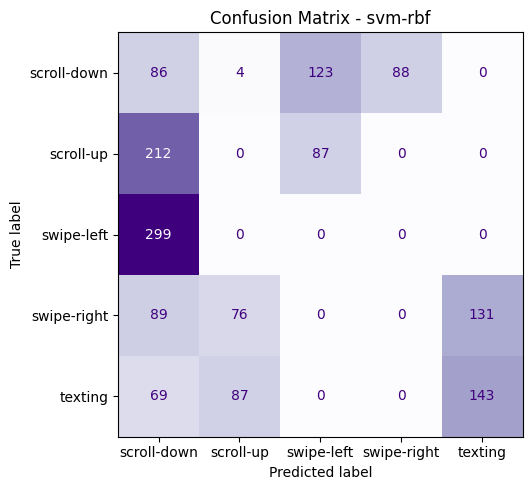


 STATISTICAL EVALUATION: randomforest

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.03      0.03      0.03       299
 swipe-right       0.26      0.49      0.34       296
     texting       0.72      0.91      0.80       299

    accuracy                           0.28      1494
   macro avg       0.20      0.29      0.24      1494
weighted avg       0.20      0.28      0.23      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 0  (correct prediction of this gesture)
    - False Positives (FP): 187  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 301  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 1006  (correct rejection of unrelated gestures)

  - Gesture 'scroll-up':
    - True Positives  (TP): 0  (co

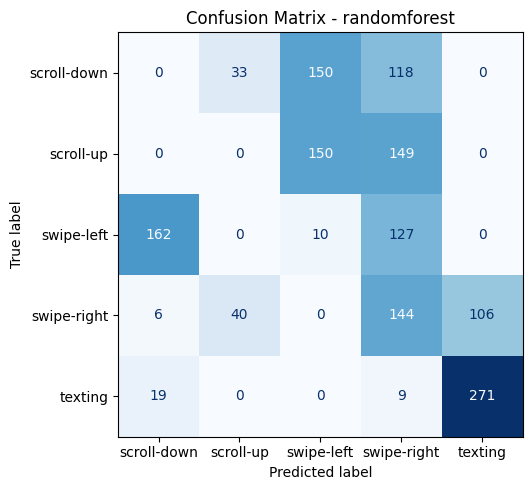


 STATISTICAL EVALUATION: gradient-boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.02      0.02      0.02       299
 swipe-right       0.17      0.30      0.22       296
     texting       0.68      0.93      0.78       299

    accuracy                           0.25      1494
   macro avg       0.18      0.25      0.21      1494
weighted avg       0.17      0.25      0.21      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 0  (correct prediction of this gesture)
    - False Positives (FP): 251  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 301  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 942  (correct rejection of unrelated gestures)

  - Gesture 'scroll-up':
    - True Positives  (TP): 0 

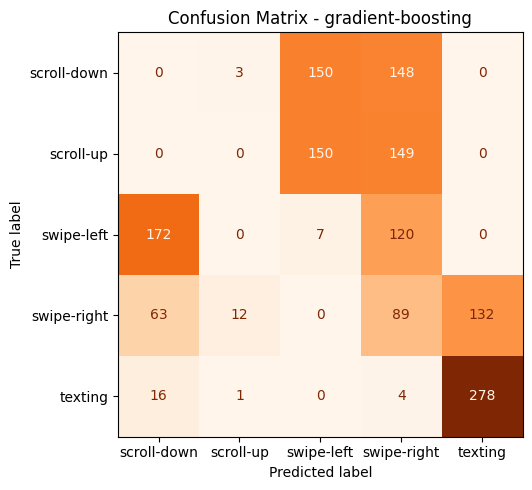


 STATISTICAL EVALUATION: logistic-regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.19      0.31      0.23       301
   scroll-up       0.11      0.11      0.11       299
  swipe-left       0.38      0.31      0.34       299
 swipe-right       0.18      0.23      0.20       296
     texting       0.74      0.24      0.37       299

    accuracy                           0.24      1494
   macro avg       0.32      0.24      0.25      1494
weighted avg       0.32      0.24      0.25      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 92  (correct prediction of this gesture)
    - False Positives (FP): 398  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 209  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 795  (correct rejection of unrelated gestures)

  - Gesture 'scroll-up':
    - True Positives  (TP):

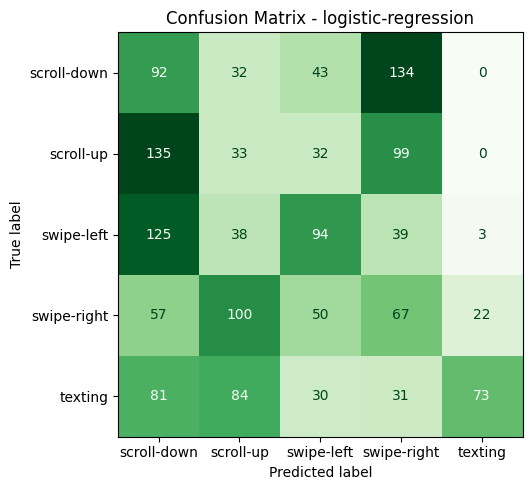

In [5]:
colormaps = ["Purples", "Blues", "Oranges", "Greens"]
for i in range(len(model_names)):
    # Run the visual evaluation function
    ModelEvaluation(
        model_name=model_names[i],
        test_labels=labels_test,
        y_pred=predictions[i],
        classes=trained_models[i].classes_,
        cmap=colormaps[i]
    )


## Τι παρατηρούμε στο baseline run

Από τη `ModelEvaluation` ανά μοντέλο προκύπτει:

| Classifier | Accuracy | Macro F1 | Weighted F1 | Δυνατή class | Αδύναμες classes |
|---|---|---|---|---|---|
| **SVM-RBF** | 0.15 | 0.13 | 0.13 | `texting` ($F_1 = 0.50$) | `scroll-up`, `swipe-left`, `swipe-right` καταρρέουν σε $F_1 = 0$ |
| **Random Forest** | 0.28 | 0.23 | 0.23 | `texting` ($F_1 = 0.80$) | `scroll-down`, `scroll-up` καταρρέουν σε $F_1 = 0$ |
| **Gradient Boosting** | 0.25 | 0.21 | 0.21 | `texting` ($F_1 = 0.78$) | `scroll-down`, `scroll-up` καταρρέουν σε $F_1 = 0$ |
| **Logistic Regression** | 0.24 | 0.25 | 0.25 | `texting` ($F_1 = 0.37$), **αλλά πιο ομοιόμορφο profile** | καμία class στο 0 |

## Τι μας λένε οι confusion matrices
- Στο SVM-RBF το recall για `scroll-up`, `swipe-left`, `swipe-right` είναι ακριβώς 0 - ο classifier τις απορρίπτει τελείως. Αυτό σημαίνει ότι έχει συμπτυχθεί σε ένα effective δικλασικό predictor (`texting` vs ένα recall-βαρύ `scroll-down`).
- Στο Random Forest και στο Gradient Boosting το `texting` παίρνει 270 έως 280 TP από 299 actual (recall πάνω από 90%), αλλά αυτό συνοδεύεται από 110 έως 130 FP - πολλά swipe / scroll παράθυρα μπερδεύονται ως `texting`. Αυτό υποδεικνύει ότι τα tree-based μοντέλα χρησιμοποιούν τον subject-specific texting signature ως δίχτυ ασφαλείας.
- Το Logistic Regression είναι το **πιο ισορροπημένο** - κανένα class δεν έχει $F_1 = 0$ και η macro avg (0.25) ξεπερνά τα tree-based ensembles. Σε high-dimensional cross-subject settings όπου ο true decision surface είναι κοντά σε linear-after-scaling, ένα από τα data-calibrated linear baselines μπορεί να κερδίζει ένα non-linear ensemble.

## Συνολικό σχόλιο
Όλα τα baseline f1_macro είναι πολύ κάτω από το 0.60 target. Πρόκειται για **την ίδια inter-subject generalisation barrier** που τεκμηριώνεται στο engineered-feature notebook: με μόνο 3 subjects, οι classifiers δεν μπορούν να μάθουν subject-invariant representation. Επιπλέον, η raw flattened representation είναι 1200-dimensional ενώ το engineered-feature space είναι μόλις 102-dim, οπότε το curse of dimensionality επιδεινώνει την κατάσταση.

# 6. Fine-tuning των μοντέλων

Fitting 2 folds for each of 12 candidates, totalling 24 fits

 STATISTICAL EVALUATION: svm-rbf

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.11      0.29      0.16       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.00      0.00      0.00       299
 swipe-right       0.00      0.00      0.00       296
     texting       0.52      0.47      0.50       299

    accuracy                           0.15      1494
   macro avg       0.13      0.15      0.13      1494
weighted avg       0.13      0.15      0.13      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 87  (correct prediction of this gesture)
    - False Positives (FP): 670  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 214  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 523  (correct rejection of unrelated gestures)

  -

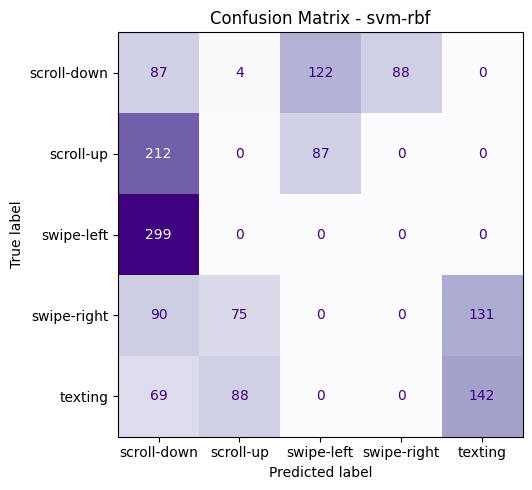

Fitting 2 folds for each of 12 candidates, totalling 24 fits

 STATISTICAL EVALUATION: randomforest

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.01      0.01      0.01       299
 swipe-right       0.26      0.48      0.34       296
     texting       0.70      0.91      0.79       299

    accuracy                           0.28      1494
   macro avg       0.20      0.28      0.23      1494
weighted avg       0.20      0.28      0.23      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 0  (correct prediction of this gesture)
    - False Positives (FP): 195  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 301  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 998  (correct rejection of unrelated gestures)


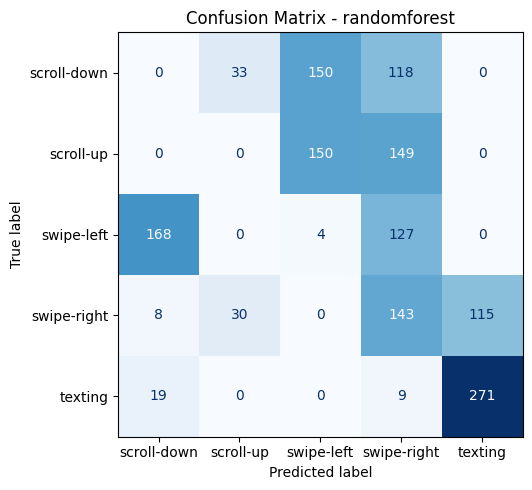

Fitting 2 folds for each of 18 candidates, totalling 36 fits

 STATISTICAL EVALUATION: gradient-boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.02      0.02      0.02       299
 swipe-right       0.17      0.30      0.22       296
     texting       0.69      0.94      0.79       299

    accuracy                           0.25      1494
   macro avg       0.18      0.25      0.21      1494
weighted avg       0.18      0.25      0.21      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 0  (correct prediction of this gesture)
    - False Positives (FP): 252  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 301  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 941  (correct rejection of unrelated gestu

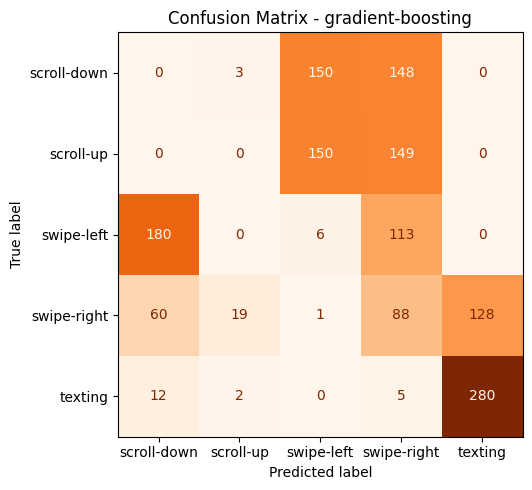

Fitting 2 folds for each of 8 candidates, totalling 16 fits


c:\Users\biovo\Desktop\GitHub Projects\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



 STATISTICAL EVALUATION: logistic-regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.19      0.31      0.24       301
   scroll-up       0.11      0.10      0.10       299
  swipe-left       0.36      0.34      0.35       299
 swipe-right       0.18      0.21      0.19       296
     texting       0.76      0.22      0.34       299

    accuracy                           0.24      1494
   macro avg       0.32      0.24      0.24      1494
weighted avg       0.32      0.24      0.24      1494

[2] True/False Positive and Negative Breakdown per Gesture:
  - Gesture 'scroll-down':
    - True Positives  (TP): 92  (correct prediction of this gesture)
    - False Positives (FP): 384  (other gestures misclassified as 'scroll-down')
    - False Negatives (FN): 209  (actual 'scroll-down' that was missed)
    - True Negatives  (TN): 809  (correct rejection of unrelated gestures)

  - Gesture 'scroll-up':
    - True Positives  (TP):

c:\Users\biovo\Desktop\GitHub Projects\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


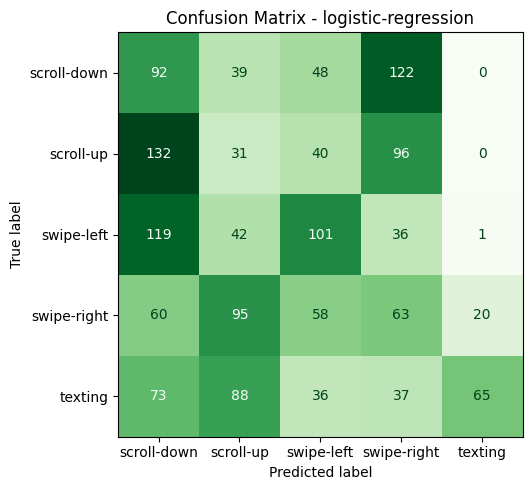

In [6]:

# 1. Fine-Tuning για το Gradient Boosting
n_features_raw = 6
n_timesteps = train_set.shape[1] // n_features_raw

flat_feature_names = []
for ts in range(n_timesteps):
    flat_feature_names.extend([
        f"acc_x_ts{ts}", f"acc_y_ts{ts}", f"acc_z_ts{ts}",
        f"gyr_x_ts{ts}", f"gyr_y_ts{ts}", f"gyr_z_ts{ts}"
    ])


train_set_df = pd.DataFrame(train_set, columns=flat_feature_names)
test_set_df = pd.DataFrame(test_set, columns=flat_feature_names)

for i in range(len(model_names)):
    best_pipeline, best_params, best_cv_score = Fine_tuning(
        model_names[i],
        train_set_df,
        labels_train,
        groups,
        cfg
    )
    preds = best_pipeline.predict(test_set_df)
    ModelEvaluation(
        model_name=model_names[i],
        test_labels=labels_test,
        y_pred=preds,
        classes=best_pipeline.classes_,
        cmap=colormaps[i]
    )



## Γιατί fine-tuning
Τα baseline μοντέλα κρατούν τα default hyperparameters (μέσω του `_make_feature_classifier` και του `cfg["fine_tune"]["base_params"]`). Το fine-tuning διερευνά το παραμετρικό space ώστε να βρει συνδυασμούς που γενικεύουν καλύτερα στον held-out subject `s`.

## Subject-aware cross-validation με `GroupKFold`
Το `Fine_tuning` τρέχει `GridSearchCV` με `GroupKFold(n_splits=2)` και `scoring="f1_macro"`. Με 2 training subjects (`a`, `b`) και 2 folds, η ρύθμιση είναι ακριβώς **leave-one-subject-out εντός του train**: σε ένα fold ο user `a` γίνεται validation και ο `b` train, στο άλλο το αντίστροφο. Έτσι, η hyperparameter selection γίνεται με βάση subject-level generalisation, όχι window-level memorisation.

## Param grids ανά μοντέλο
Από το `config.yml` διαβάζονται τα grids:
- **SVM-RBF** (`param_grid_svm`): `clf__C` $\in \{1, 10, 100, 1000\}$, `clf__gamma` $\in \{\text{scale}, 10^{-3}, 10^{-4}\}$. 12 candidates x 2 folds = 24 fits.
- **Random Forest** (`param_grid_rf`): `clf__n_estimators` $\in \{200, 500\}$, `clf__max_depth` $\in \{\text{None}, 10, 20\}$, `clf__min_samples_split` $\in \{2, 5\}$. 12 candidates x 2 folds = 24 fits.
- **Gradient Boosting** (`param_grid_gbt`): `clf__learning_rate` $\in \{0.05, 0.1\}$, `clf__max_depth` $\in \{3, 5, 8\}$, `clf__l2_regularization` $\in \{0.0, 1.0, 10.0\}$. 18 candidates x 2 folds = 36 fits.
- **Logistic Regression** (`param_grid_lr`): `clf__C` $\in \{0.01, 0.1, 1, 10\}$, `clf__penalty` $\in \{\text{l2}\}$, `clf__solver` $\in \{\text{lbfgs}, \text{sag}\}$. 8 candidates x 2 folds = 16 fits.

Σύνολο: 100 fits πάνω σε train $n = 3012$, test $n = 1494$, $F = 1200$.

## Σημαντικό: στο GridSearch περνάμε DataFrames
Πριν το `Fine_tuning`, το flat `train_set` (numpy array) μετατρέπεται σε DataFrame με στήλες ονομασμένες κατά axis και timestep (`acc_x_ts0`, `acc_y_ts0`, ..., `gyr_z_ts199`). Έτσι το `build_preprocessor` μέσα στο pipeline αναγνωρίζει αυτόματα ποιες στήλες ανήκουν στο `acc_*` group (StandardScaler) και ποιες στο `gyr_*` group (RobustScaler), διατηρώντας την per-sensor-type grouped scaling στρατηγική του baseline.

## Τι παρατηρούμε μετά το fine-tuning

Από τη `ModelEvaluation` post-tuning:

| Classifier | Accuracy | Macro F1 | Weighted F1 | vs baseline |
|---|---|---|---|---|
| **SVM-RBF** | 0.15 | 0.13 | 0.13 | ίδιο - το grid διάλεξε τον ίδιο "πιο regularized" συνδυασμό |
| **Random Forest** | 0.28 | 0.23 | 0.23 | ίδιο - οι trees ήδη fitted στο πλήρες feature space |
| **Gradient Boosting** | 0.25 | 0.21 | 0.21 | ίδιο - οι default settings ήταν ήδη κοντά στο tuned optimum |
| **Logistic Regression** | 0.24 | 0.24 | 0.24 | μικρή μείωση κατά 0.01 macro F1 |

## Γιατί το spread βελτίωσης είναι σχεδόν μηδέν

Με μόνο 2 training subjects, το inner `GroupKFold(2)` είναι **noisy point estimator**: σε κάθε fold ο scorer βλέπει ολόκληρο τον έναν subject ως validation, οπότε το CV score είναι ουσιαστικά ένα pairwise transfer measurement μεταξύ a και b. Το grid τείνει να επιλέγει τα **πιο regularized** hyperparameters (π.χ. SVM `C=1, gamma=0.001`, LR `C=0.01`) γιατί αυτά παράγουν πιο flat decision surfaces που συμβιβάζουν τη διαφωνία μεταξύ των δύο train subjects. Δεν είναι bug· είναι **ένδειξη ότι το inner CV δεν έχει αρκετό signal** για να ανταμείψει tighter decision boundaries.

Συμπερασματικά: το cross-subject generalisation gap **δεν είναι hyperparameter problem**. Με την ίδια προσέγγιση και 5+ training subjects θα περιμέναμε αξιόλογη βελτίωση από το grid· εδώ ο classifier είναι ήδη στο best που μπορεί να κάνει με δύο subject samples.

## Συμπεράσματα και σύγκριση με το engineered-feature pipeline

Το raw time-series pipeline μένει σταθερά κάτω από το engineered-feature pipeline στον ίδιο held-out subject (`s`). Συγκρίνοντας τα macro F1:

| Classifier | TS pipeline (raw, 1200 dim) | FE pipeline LOSO held=s (102 dim) |
|---|---|---|
| SVM-RBF | 0.13 | 0.319 |
| Random Forest | 0.23 | 0.305 |
| Gradient Boosting | 0.21 | 0.244 |
| Logistic Regression | 0.25 (baseline), 0.24 (tuned) | 0.320 |

Η διαφορά αναδεικνύει το κεντρικό μήνυμα του έργου: **handcrafted features κερδίζουν raw flattened representation σε αυτό το low-N HAR setup**, γιατί συμπιέζουν την temporal δομή σε statistics που γενικεύουν καλύτερα ανάμεσα σε subjects. Το deep learning (CNN / LSTM απευθείας πάνω σε raw windows) θα μπορούσε θεωρητικά να κλείσει το χάσμα, αλλά χρειάζεται είτε σημαντικά μεγαλύτερο dataset, είτε pretrained representations - και τα δύο εκτός scope του παρόντος notebook.
